# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import probplot

# Data loading

In [2]:
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [3]:
X = non_smoker_df['age'].to_frame()
y = non_smoker_df['charges']

print("Дизайн матриця")
display(X)
print("Цільова змінна")
display(y)

Дизайн матриця


,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


Цільова змінна


1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

### Least squares method

Data preparation

In [4]:
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

print("Дизайн матриця з урахуванням константи")
display(X_with_intercept)

Дизайн матриця з урахуванням константи


array([[ 1., 18.],
       [ 1., 28.],
       [ 1., 33.],
       ...,
       [ 1., 18.],
       [ 1., 18.],
       [ 1., 21.]], shape=(1064, 2))

Finding optimal values ​​of model coefficients

In [5]:
def least_square_method(X, y):
    theta = np.linalg.inv(np.dot(X.T, X)).dot(X.T).dot(y)
    return theta

In [6]:
LSM_coef = least_square_method(X_with_intercept, y)

In [7]:
print('Константа:', LSM_coef[0].round(4))
print("Коефіцієнт ознаки age:", LSM_coef[1].round(4))

Константа: -2091.4206
Коефіцієнт ознаки age: 267.2489


Forecasting the target variable

In [8]:
prediction_LSM = np.dot(X_with_intercept, LSM_coef)

print("Прогнозування charges на основі Методу найменших квадратів")
display(prediction_LSM)

Прогнозування charges на основі Методу найменших квадратів


array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

Model quality analysis

In [9]:
def rmse(prediction, y):
    rmse = np.sqrt(np.sum(np.square(y - prediction))/ y.shape[0])
    return rmse

In [10]:
rmse_LSM = np.sqrt(mean_squared_error(y, prediction_LSM))
print("Середньо квадратична помилка розрахована з бібліотеки:", rmse_LSM.round(4))

Середньо квадратична помилка розрахована з бібліотеки: 4662.5058


In [11]:
rmse_LSM_func = rmse(prediction_LSM, y)
r2_LSM = r2_score(y, prediction_LSM)

print("Середньо квадратична помилка:", rmse_LSM_func.round(4))
print("Коефіцієнт детермінації:", round(r2_LSM, 4))

Середньо квадратична помилка: 4662.5058
Коефіцієнт детермінації: 0.3943


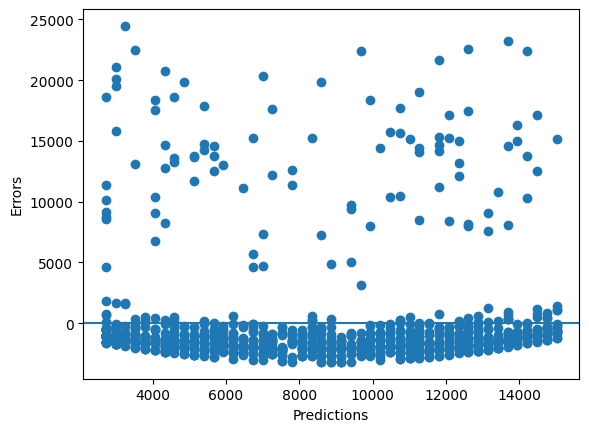

In [12]:
errors_LSM = y - prediction_LSM

plt.scatter(prediction_LSM, errors_LSM)
plt.xlabel("Predictions")
plt.ylabel("Errors")
plt.axhline(0)
plt.show();

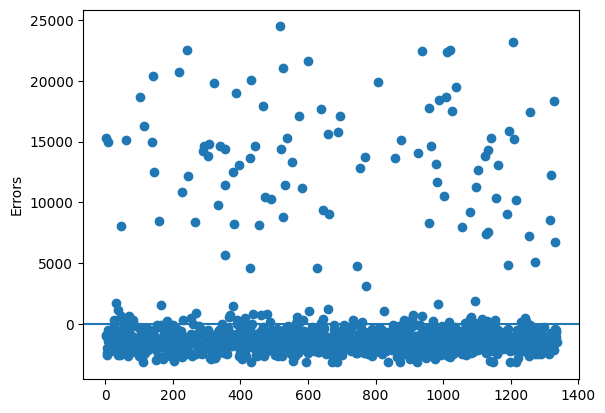

In [13]:
plt.plot(errors_LSM, 'o')
plt.ylabel("Errors")
plt.axhline(0)
plt.show();

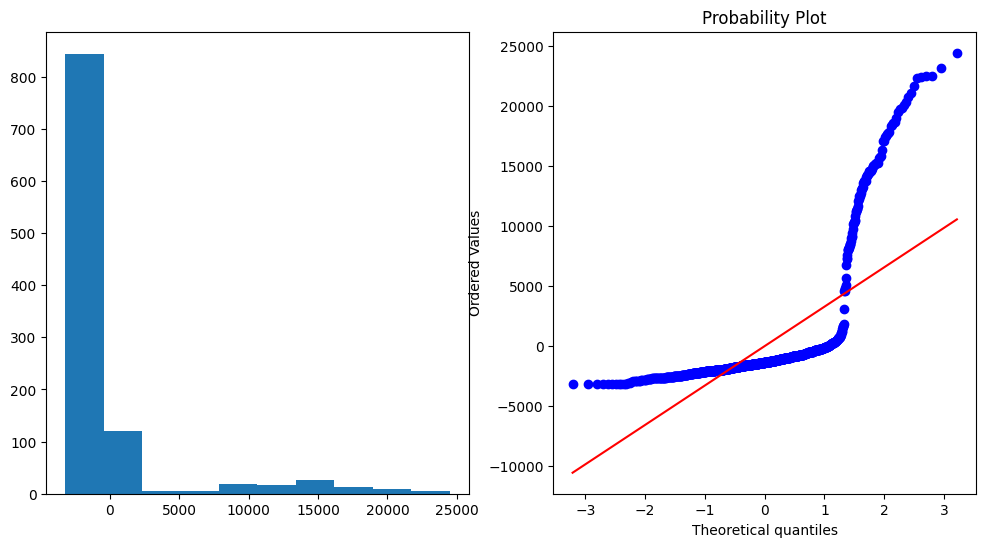

In [14]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(errors_LSM)
plt.subplot(1,2,2)
probplot(errors_LSM, dist='norm', plot=plt);

Visual representation of results

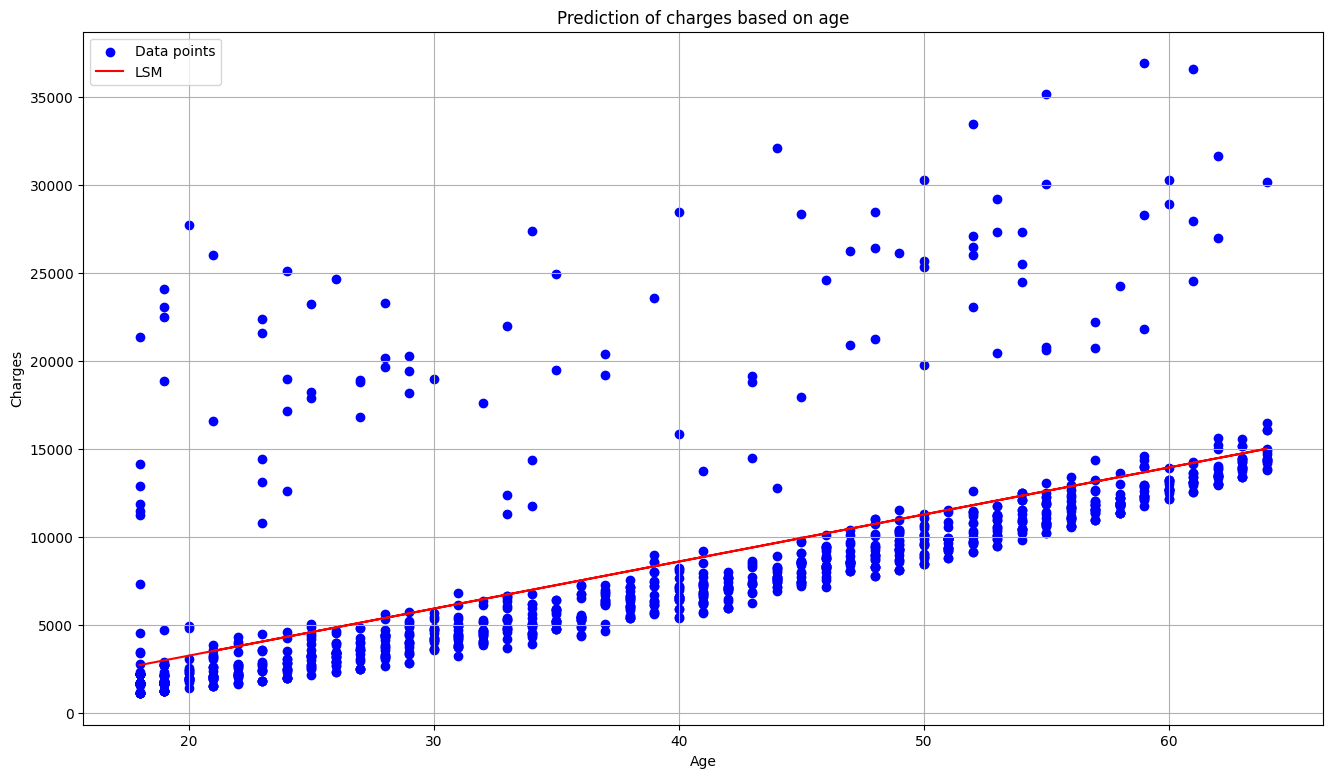

In [15]:
plt.figure(figsize = (16, 9))
plt.scatter(X, y, color = 'blue', label = 'Data points')
plt.plot(X, prediction_LSM, color = 'red', label = 'LSM')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Prediction of charges based on age")
plt.legend()
plt.grid(True)
plt.show()

A linear univariate model was constructed using the Least Squares Method, which reflects the relationship between medical fees and the age of non-smokers.

It describes only 39.43% of the data of the modeled characteristic due to age, the remaining 60.07% of the data depend on other variables. The mean square error is 4662.51 USD. US dollars. At the same time, the distribution of the residuals is not a normal distribution, respectively, the results may not be statistically significant. Regarding heteroscedasticity, there are "two clouds" of residuals without a clear trend, which tends more towards homoscedasticity. However, given the results of the forecasting and distribution of residuals, the modeling of the dependent variable should be continued taking into account other characteristics.

### Full-batch gradient descent

In [16]:
X_gr = X.to_numpy()[:, 0]
y_gr = y.to_numpy()

Finding optimal model coefficients

In [17]:
def full_batch_gradient_descent(X, y, lr = 0.1, epochs = 1000):

    m, b = 0.0, 0.0
    n = len(y)
    errors = []

    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(np.sum(error**2))
        m_gradient = (2 / n) * np.dot(error, X)
        b_gradient = (2 / n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [18]:
m, b, errors = full_batch_gradient_descent(X_gr, y_gr, lr = 0.1, epochs = 1000)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_40080\1841443441.py:10: RuntimeWarning: overflow encountered in square
  errors.append(np.sum(error**2))
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_40080\1841443441.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


In [19]:
m_4, b_4, errors_4 = full_batch_gradient_descent(X_gr, y_gr, lr = 1e-4, epochs = 1000)

print("При рівні learning rate = 1e-4")
print('Константа:', m_4.round(4))
print("Коефіцієнт ознаки age:", b_4.round(4))

При рівні learning rate = 1e-4
Константа: 221.1046
Коефіцієнт ознаки age: -41.9813


In [20]:
m_5, b_5, errors_5 = full_batch_gradient_descent(X_gr, y_gr, lr = 1e-5, epochs = 1000)

print("При рівні learning rate = 1e-5")
print('Константа:', m_5.round(4))
print("Коефіцієнт ознаки age:", b_5.round(4))

При рівні learning rate = 1e-5
Константа: 220.1546
Коефіцієнт ознаки age: 0.213


In [21]:
m_6, b_6, errors_6 = full_batch_gradient_descent(X_gr, y_gr, lr = 1e-6, epochs = 1000)

print("При рівні learning rate = 1e-6")
print('Константа:', m_6.round(4))
print("Коефіцієнт ознаки age:", b_6.round(4))

При рівні learning rate = 1e-6
Константа: 213.4576
Коефіцієнт ознаки age: 4.3312


In [22]:
m_8, b_8, errors_8 = full_batch_gradient_descent(X_gr, y_gr, lr = 1e-8, epochs = 1000)

print("При рівні learning rate = 1e-8")
print('Константа:', m_8.round(4))
print("Коефіцієнт ознаки age:", b_8.round(4))

При рівні learning rate = 1e-8
Константа: 7.5697
Коефіцієнт ознаки age: 0.1657


In [23]:
m_10, b_10, errors_10 = full_batch_gradient_descent(X_gr, y_gr, lr = 1e-10, epochs = 1000)

print("При рівні learning rate = 1e-10")
print('Константа:', m_10.round(4))
print("Коефіцієнт ознаки age:", b_10.round(4))

При рівні learning rate = 1e-10
Константа: 0.077
Коефіцієнт ознаки age: 0.0017


In [24]:
m_12, b_12, errors_12 = full_batch_gradient_descent(X_gr, y_gr, lr = 1e-12, epochs = 1000)

print("При рівні learning rate = 1e-12")
print('Константа:', m_12.round(4))
print("Коефіцієнт ознаки age:", b_12.round(4))

При рівні learning rate = 1e-12
Константа: 0.0008
Коефіцієнт ознаки age: 0.0


Forecasting the target variable

In [25]:
prediction_4 = m_4 * X_gr + b_4
prediction_5 = m_5 * X_gr + b_5
prediction_6 = m_6 * X_gr + b_6
prediction_8 = m_8 * X_gr + b_8
prediction_10 = m_10 * X_gr + b_10
prediction_12 = m_12 * X_gr + b_12

print("Прогнозування charges на основі full-batch градієнтного спуску")

prediction_full_batch_gradient = pd.DataFrame({
    "y_pred lr = 1e-4": prediction_4,
    "y_pred lr = 1e-5": prediction_5,
    "y_pred lr = 1e-6": prediction_6,
    "y_pred lr = 1e-8": prediction_8,
    "y_pred lr = 1e-10": prediction_10,
    "y_pred lr = 1e-12": prediction_12,
})

prediction_full_batch_gradient

Прогнозування charges на основі full-batch градієнтного спуску


,y_pred lr = 1e-4,y_pred lr = 1e-5,y_pred lr = 1e-6,y_pred lr = 1e-8,y_pred lr = 1e-10,y_pred lr = 1e-12
0,3937.901250,3962.995006,3846.567492,136.421045,1.387961,0.013882
1,6148.947094,6164.540561,5981.143183,212.118465,2.158113,0.021585
2,7254.470016,7265.313338,7048.431028,249.967175,2.543189,0.025436
3,7033.365432,7045.158783,6834.973459,242.397433,2.466174,0.024666
4,6812.260847,6825.004227,6621.515890,234.827691,2.389159,0.023896
...,...,...,...,...,...,...
1059,11455.457119,11448.249893,11104.124841,393.792274,4.006479,0.040072
1060,11013.247950,11007.940782,10677.209702,378.652790,3.852448,0.038531
1061,3937.901250,3962.995006,3846.567492,136.421045,1.387961,0.013882
1062,3937.901250,3962.995006,3846.567492,136.421045,1.387961,0.013882


Model quality analysis

In [26]:
rmse_gr_4 = rmse(prediction_4, y_gr)
rmse_gr_5 = rmse(prediction_5, y_gr)
rmse_gr_6 = rmse(prediction_6, y_gr)
rmse_gr_8 = rmse(prediction_4, y_gr)
rmse_gr_10 = rmse(prediction_10, y_gr)
rmse_gr_12 = rmse(prediction_12, y_gr)

print("Середньоквадратична помилка для моделей full-batch градієнтного спуску")

rmse_full_batch_gradient = pd.Series({
    "rmse lr = 1e-4": rmse_gr_4,
    "rmse lr = 1e-5": rmse_gr_5,
    "rmse lr = 1e-6": rmse_gr_6,
    "rmse lr = 1e-8": rmse_gr_8,
    "rmse lr = 1e-10": rmse_gr_10,
    "rmse lr = 1e-12": rmse_gr_12,
})

rmse_full_batch_gradient

Середньоквадратична помилка для моделей full-batch градієнтного спуску


rmse lr = 1e-4      4713.250583
rmse lr = 1e-5      4715.349750
rmse lr = 1e-6      4723.647721
rmse lr = 1e-8      4713.250583
rmse lr = 1e-10    10342.591350
rmse lr = 1e-12    10345.431074
dtype: float64

In [27]:
r2_gr_4 = r2_score(y_gr, prediction_4)
r2_gr_5 = r2_score(y_gr, prediction_5)
r2_gr_6 = r2_score(y_gr, prediction_6)
r2_gr_8 = r2_score(y_gr, prediction_8)
r2_gr_10 = r2_score(y_gr, prediction_10)
r2_gr_12 = r2_score(y_gr, prediction_12)

print("Коефіцієнт детермінації для моделей full-batch графієнтного спуску")

r2_full_batch_gradient = pd.Series({
    "R^2 lr = 1e-4": r2_gr_4,
    "R^2 lr = 1e-5": r2_gr_5,
    "R^2 lr = 1e-6": r2_gr_6,
    "R^2 lr = 1e-8": r2_gr_8,
    "R^2 lr = 1e-10": r2_gr_10,
    "R^2 lr = 1e-12": r2_gr_12,
})

r2_full_batch_gradient

Коефіцієнт детермінації для моделей full-batch графієнтного спуску


R^2 lr = 1e-4     0.381061
R^2 lr = 1e-5     0.380510
R^2 lr = 1e-6     0.378328
R^2 lr = 1e-8    -1.822249
R^2 lr = 1e-10   -1.980336
R^2 lr = 1e-12   -1.981973
dtype: float64

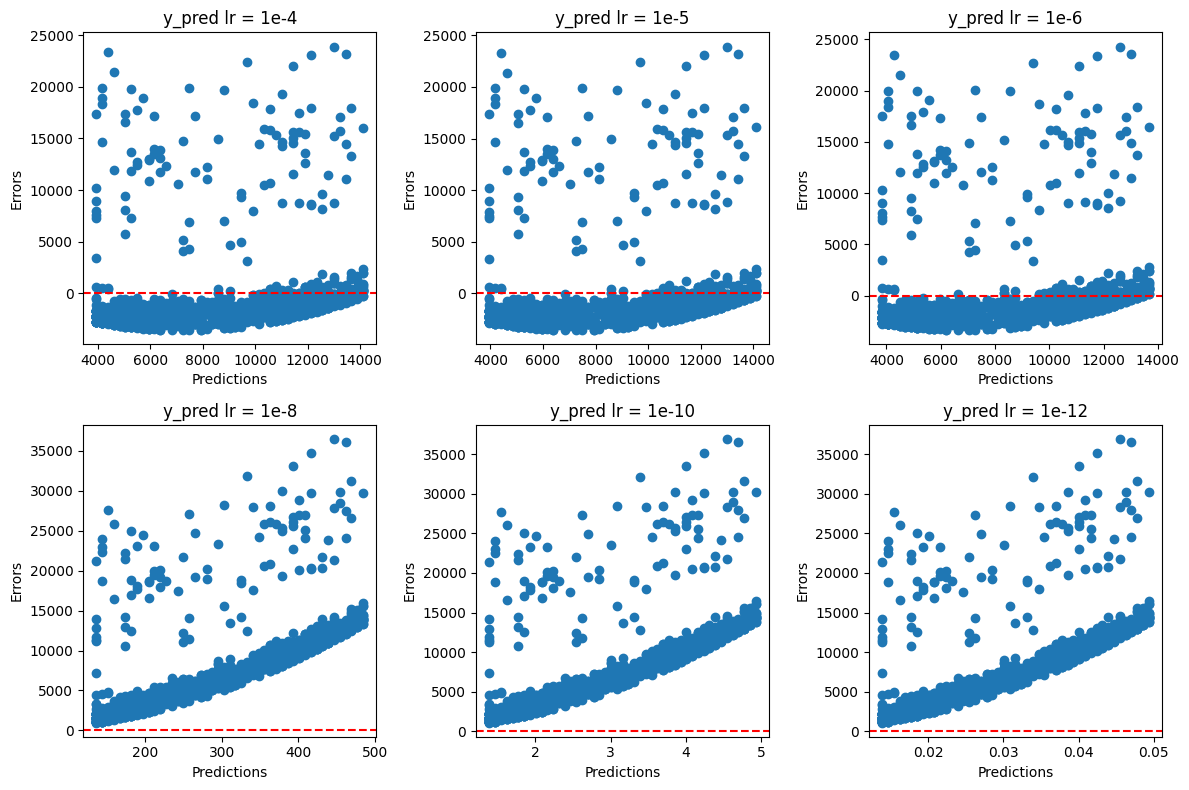

In [28]:
fig, axes = plt.subplots(2, 3, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(prediction_full_batch_gradient.columns):
    errors = y_gr - prediction_full_batch_gradient[col]
    axes[i].scatter(prediction_full_batch_gradient[col], errors)
    axes[i].axhline(0, color = 'red', linestyle = '--')
    axes[i].set_xlabel("Predictions")
    axes[i].set_ylabel("Errors")
    axes[i].set_title(col)

plt.tight_layout()
plt.show();

Dependence of error on iteration

In [29]:
errors_full_batch_gradient = pd.DataFrame({
    "lr = 1e-4": errors_4,
    "lr = 1e-5": errors_5,
    "lr = 1e-6": errors_6,
    "lr = 1e-8": errors_8,
    "lr = 1e-10": errors_10,
    "lr = 1e-12": errors_12,
})

errors_full_batch_gradient

,lr = 1e-4,lr = 1e-5,lr = 1e-6,lr = 1e-8,lr = 1e-10,lr = 1e-12
0,1.138784e+11,1.138784e+11,1.138784e+11,1.138784e+11,1.138784e+11,1.138784e+11
1,6.177138e+10,1.076727e+11,1.132479e+11,1.138720e+11,1.138783e+11,1.138784e+11
2,3.975952e+10,1.018939e+11,1.126217e+11,1.138657e+11,1.138782e+11,1.138784e+11
3,3.046092e+10,9.651264e+10,1.120000e+11,1.138594e+11,1.138782e+11,1.138784e+11
4,2.653284e+10,9.150150e+10,1.113826e+11,1.138531e+11,1.138781e+11,1.138784e+11
...,...,...,...,...,...,...
995,2.363659e+10,2.365754e+10,2.374377e+10,1.078076e+11,1.138155e+11,1.138777e+11
996,2.363657e+10,2.365754e+10,2.374318e+10,1.078017e+11,1.138155e+11,1.138777e+11
997,2.363654e+10,2.365754e+10,2.374260e+10,1.077958e+11,1.138154e+11,1.138777e+11
998,2.363652e+10,2.365754e+10,2.374202e+10,1.077899e+11,1.138154e+11,1.138777e+11


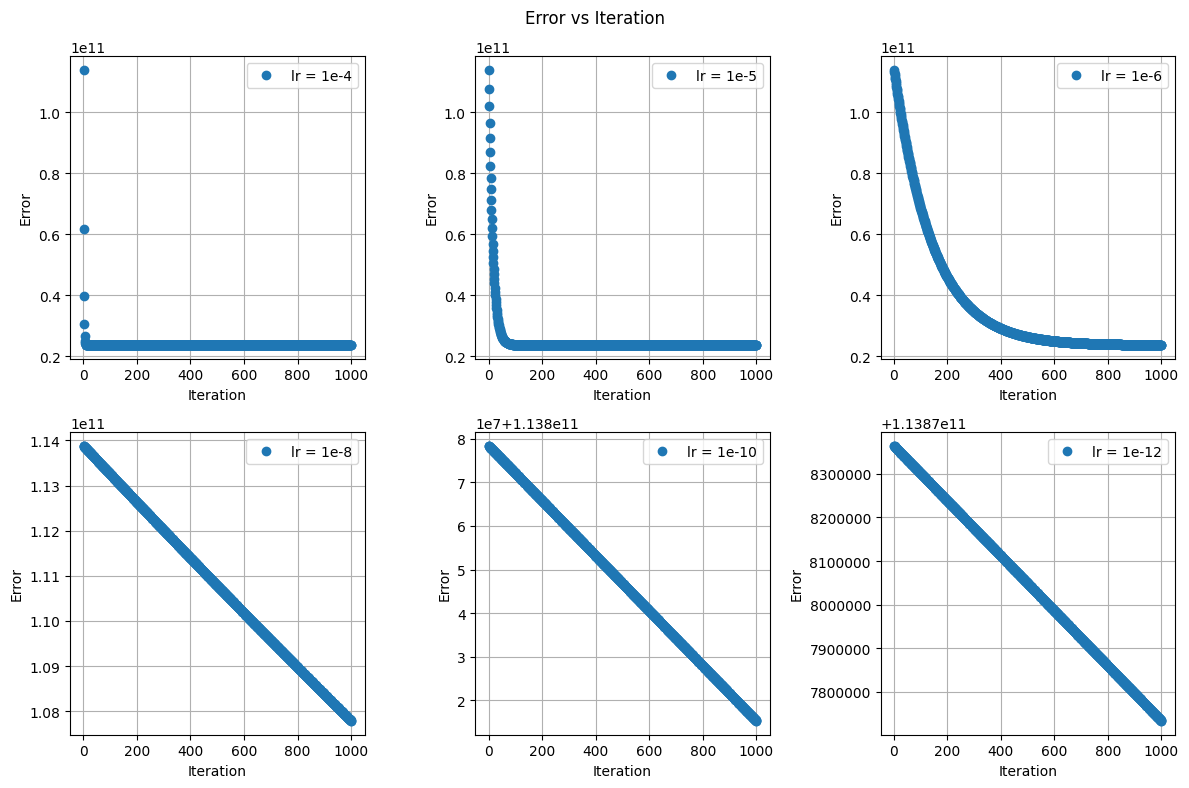

In [30]:
fig, axes = plt.subplots(2, 3, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(errors_full_batch_gradient.columns):
    axes[i].plot(range(1, len(errors_full_batch_gradient) + 1), errors_full_batch_gradient[col], 'o', label = col)
    axes[i].set_xlabel("Iteration")
    axes[i].set_ylabel("Error")
    axes[i].legend()
    axes[i].grid(True)

fig.suptitle("Error vs Iteration")
plt.tight_layout()
plt.show();

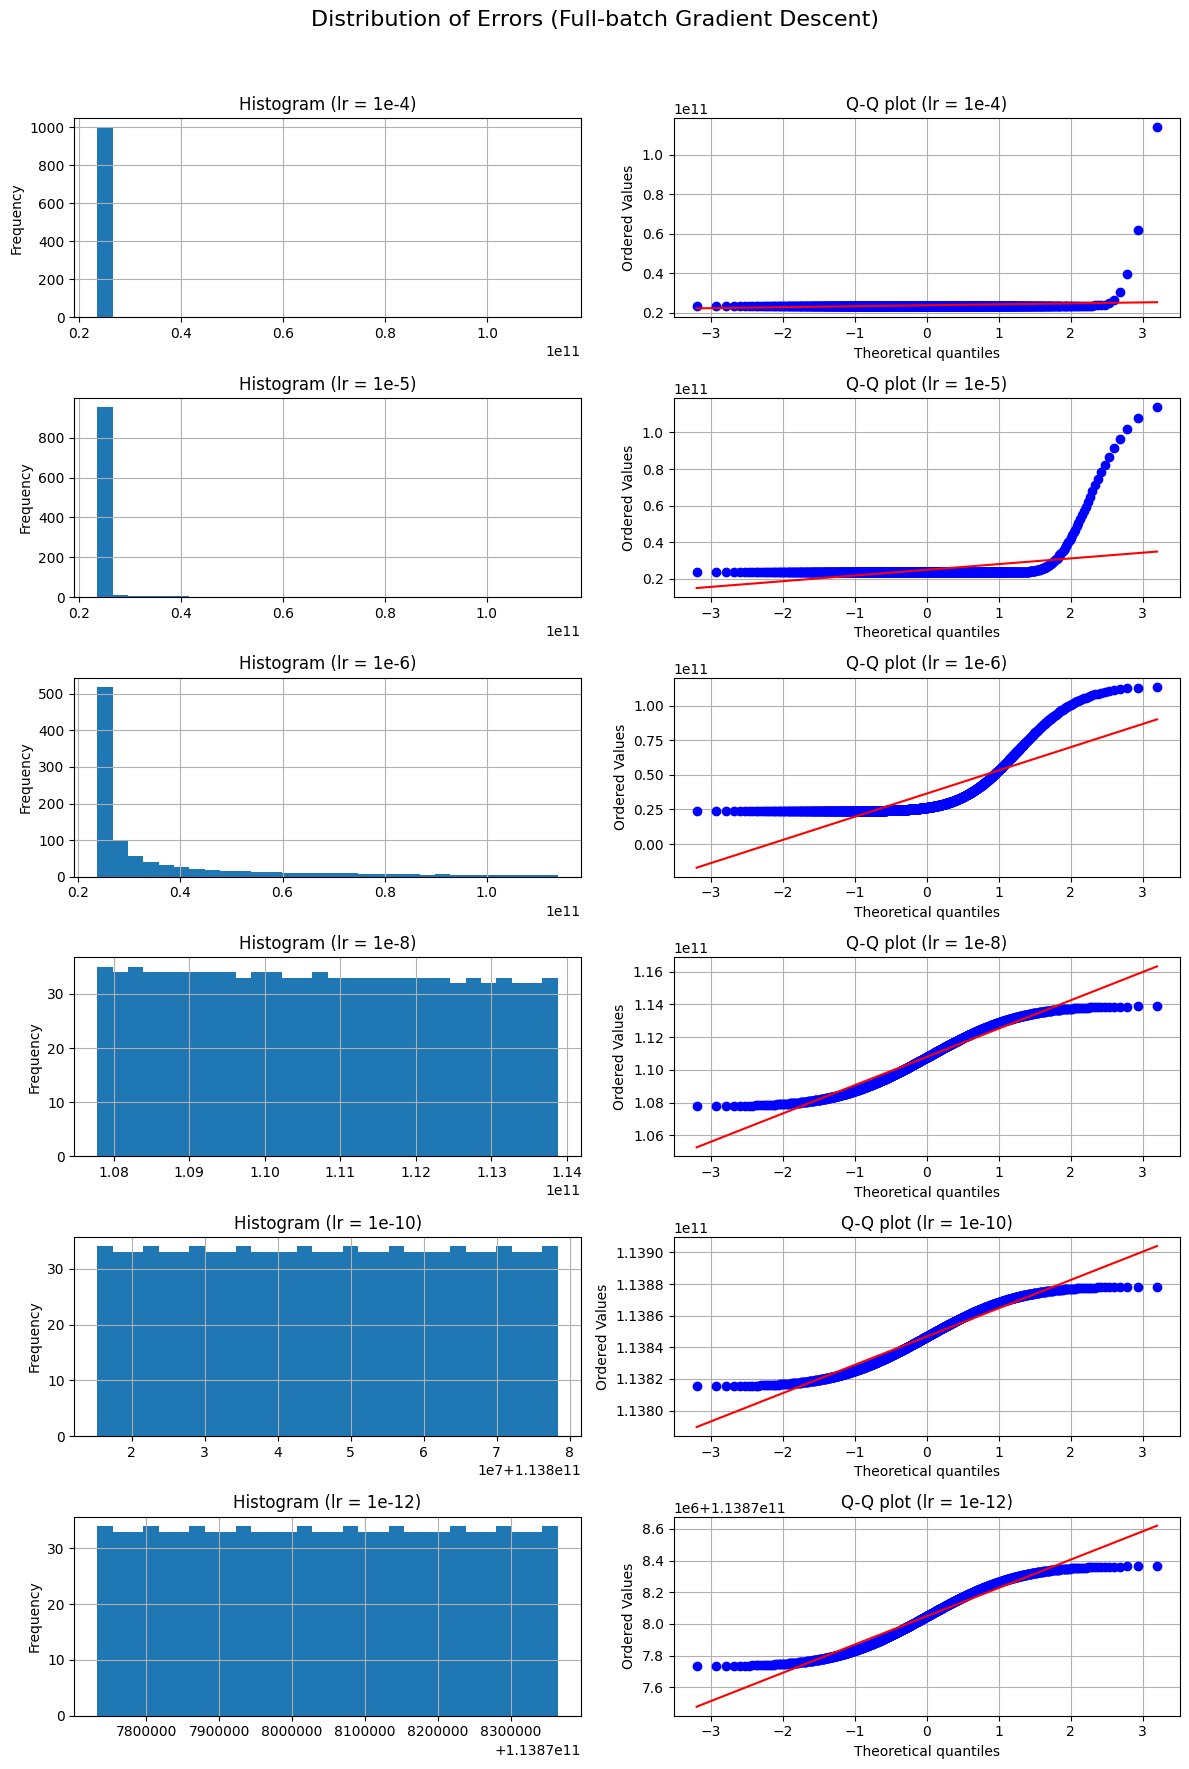

In [31]:
fig, axes = plt.subplots(6, 2, figsize=(12, 18))

for i, col in enumerate(errors_full_batch_gradient.columns):
    errors = errors_full_batch_gradient[col]

    axes[i, 0].hist(errors, bins=30)
    axes[i, 0].set_title(f"Histogram ({col})")
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].grid(True)

    probplot(errors, dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f"Q-Q plot ({col})")
    axes[i, 1].grid(True)

fig.suptitle("Distribution of Errors (Full-batch Gradient Descent)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show();

Visual representation of results

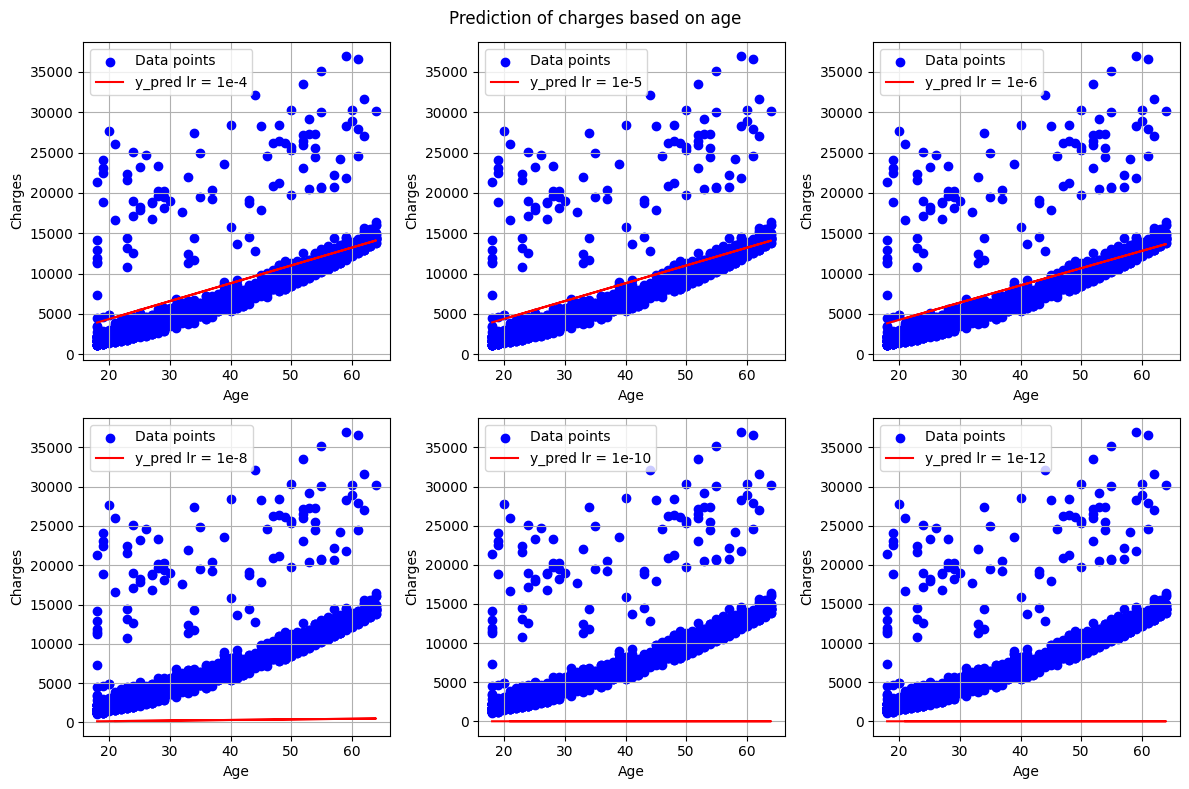

In [32]:
fig, axes = plt.subplots(2, 3, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(prediction_full_batch_gradient.columns):
    axes[i].scatter(X_gr, y_gr, color = 'blue', label = 'Data points')
    axes[i].plot(X_gr, prediction_full_batch_gradient[col], color = 'red', label = col)
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Charges")
    axes[i].legend()
    axes[i].grid(True)

fig.suptitle("Prediction of charges based on age")
plt.tight_layout()
plt.show();

A linear univariate model was constructed using full-package graph descent, which reflects the relationship between medical fees and the age of non-smokers.

With the number of epochs of 1000 and a learning rate of more than 1e-4, the model does not reach convergence. During the experiment, the following learning rates were selected - 1e-4, 1e-5, 1e-6, 1e-8, 1e-10, 1e-12.

The best result was obtained in the case of 1e-4, in this case, the studied dependence describes 38.11% of the data due to the age feature, the remaining 61.89% corresponds to the influence of other factors. The root mean square error is 4713.25 USD.
In this case, the distribution of the residuals is not a normal distribution, respectively, the results may not be statistically significant. Regarding heteroscedasticity, according to the residual plot, there is a slight trend indicating heteroscedasticity.

In cases of learning rate at the level of 1e-8, 1e-10 or 1e-12, the model does not describe the studied dependence and its use is not possible.

Therefore, the modeling should be continued taking into account other features.

### Least squares method with sklearn

Finding optimal values ​​of model coefficients

In [33]:
lin_reg = LinearRegression().fit(X, y)

In [34]:
print('Константа:', lin_reg.intercept_.round(4))
print("Коефіцієнт ознаки age:", lin_reg.coef_[0].round(4))

Константа: -2091.4206
Коефіцієнт ознаки age: 267.2489


Forecasting the target variable

In [35]:
prediction_lin_reg = lin_reg.predict(X)

print("Прогнозування charges на основі Методу найменших квадратів з sklearn")
display(prediction_lin_reg)

Прогнозування charges на основі Методу найменших квадратів з sklearn


array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

Model quality analysis

In [36]:
rmse_lin_reg = rmse(prediction_lin_reg, y)
r2_lin_reg = r2_score(y, prediction_lin_reg)

print("Середньо квадратична помилка:", rmse_lin_reg.round(4))
print("Коефіцієнт детермінації:", round(r2_lin_reg, 4))

Середньо квадратична помилка: 4662.5058
Коефіцієнт детермінації: 0.3943


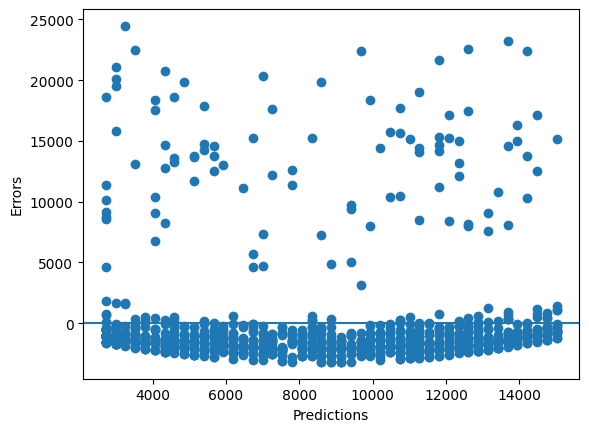

In [37]:
errors_lin_reg = y - prediction_lin_reg

plt.scatter(prediction_lin_reg, errors_lin_reg)
plt.xlabel("Predictions")
plt.ylabel("Errors")
plt.axhline(0)
plt.show();

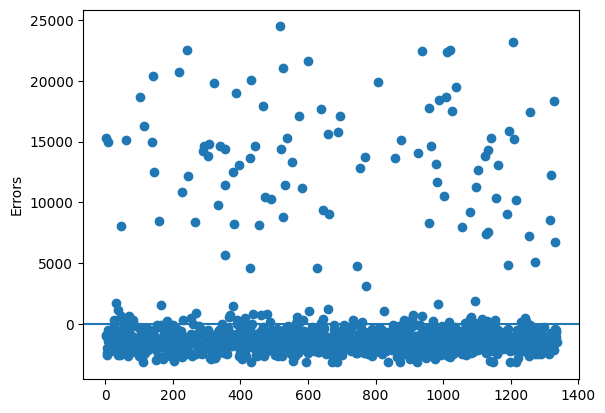

In [38]:
plt.plot(errors_lin_reg, 'o')
plt.ylabel("Errors")
plt.axhline(0)
plt.show();

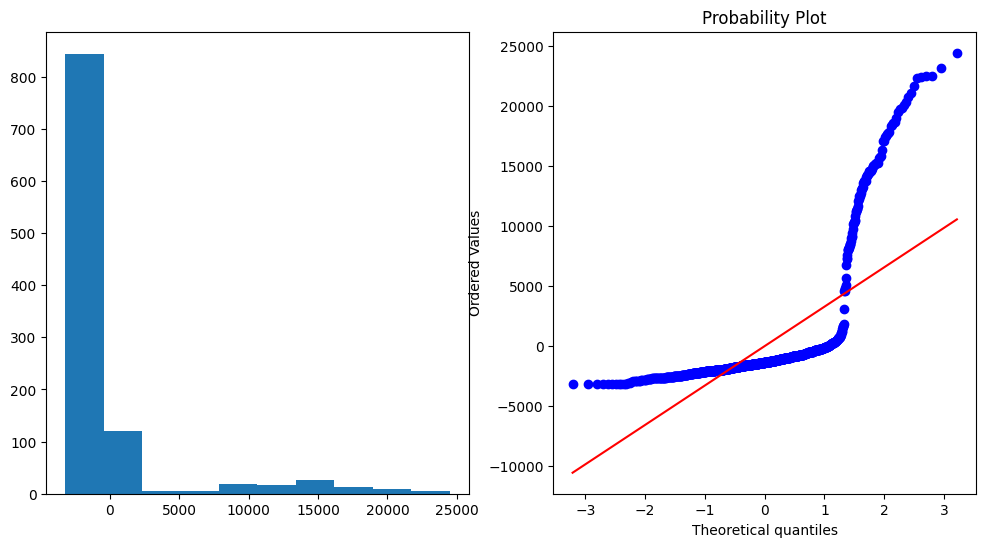

In [39]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(errors_lin_reg)
plt.subplot(1,2,2)
probplot(errors_lin_reg, dist='norm', plot=plt);

Visual representation of results

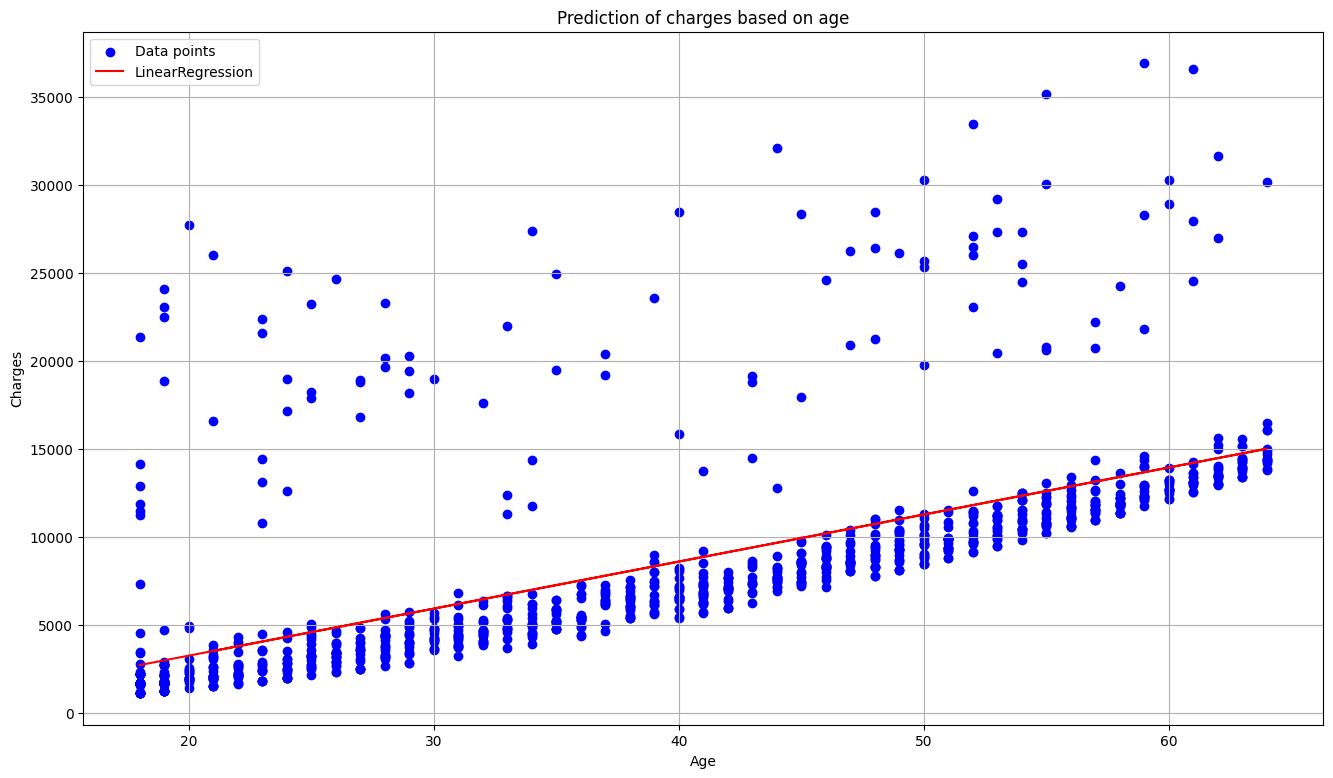

In [40]:
plt.figure(figsize = (16, 9))
plt.scatter(X, y, color = 'blue', label = 'Data points')
plt.plot(X, prediction_lin_reg, color = 'red', label = 'LinearRegression')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Prediction of charges based on age")
plt.legend()
plt.grid(True)
plt.show()

A linear univariate model was constructed using LinearRegression in the sklearn library, which reflects the relationship between medical fees and age of non-smokers.

The model describes only 39.43% of the data of the modeled characteristic due to age, the remaining 60.07% of the data depend on other variables. The mean square error is 4662.51 USD. US dollars. In this case, the distribution of the residuals is not a normal distribution, respectively, the results may not be statistically significant. Regarding heteroscedasticity, there are "two clouds" of residuals without a clear trend, which tends more towards homoscedasticity.

In this case, as in the case of previous results, the modeling should be continued taking into account other characteristics.

### Model comparison

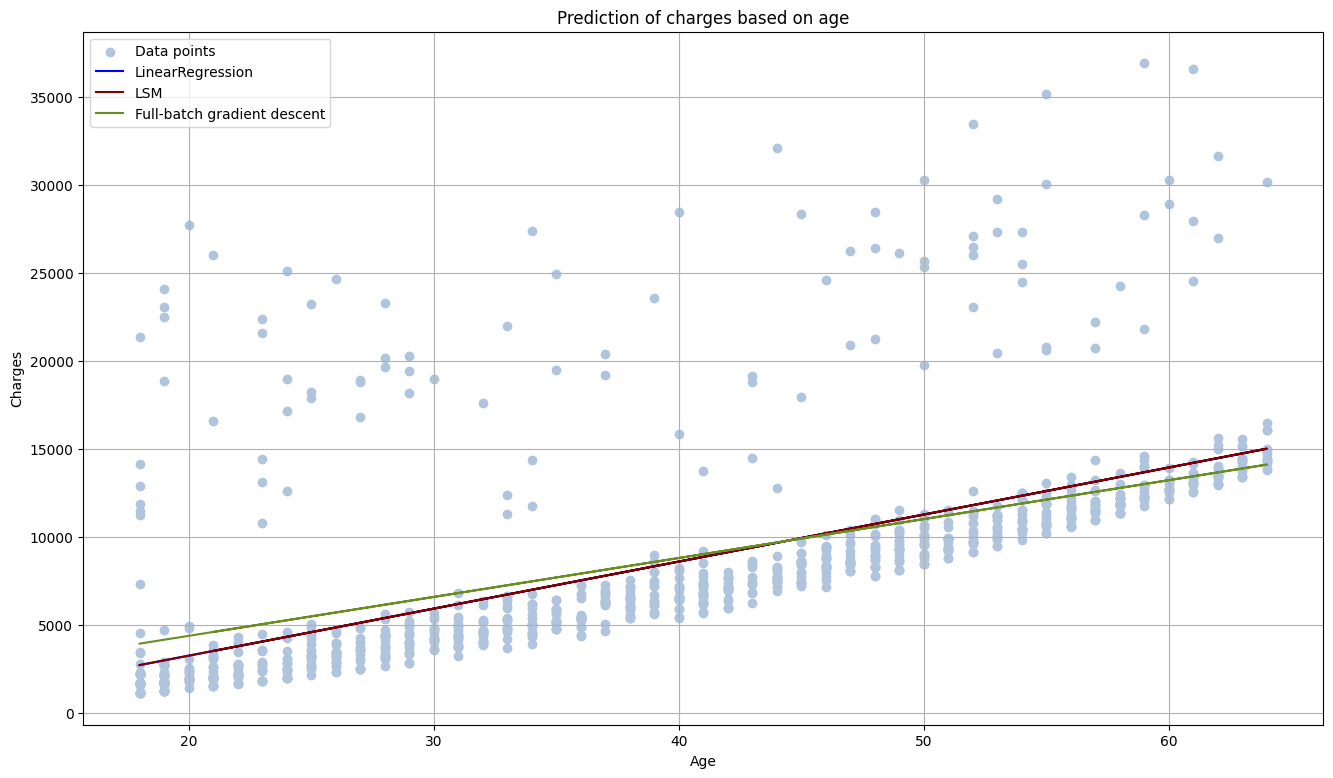

In [41]:
plt.figure(figsize = (16, 9))
plt.scatter(X, y, color = 'lightsteelblue', label = 'Data points')
plt.plot(X, prediction_lin_reg, color = 'blue', label = 'LinearRegression')
plt.plot(X, prediction_LSM, color = 'maroon', label = 'LSM')
plt.plot(X, prediction_4, color = 'olivedrab', label = 'Full-batch gradient descent')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Prediction of charges based on age")
plt.legend()
plt.grid(True)
plt.show()

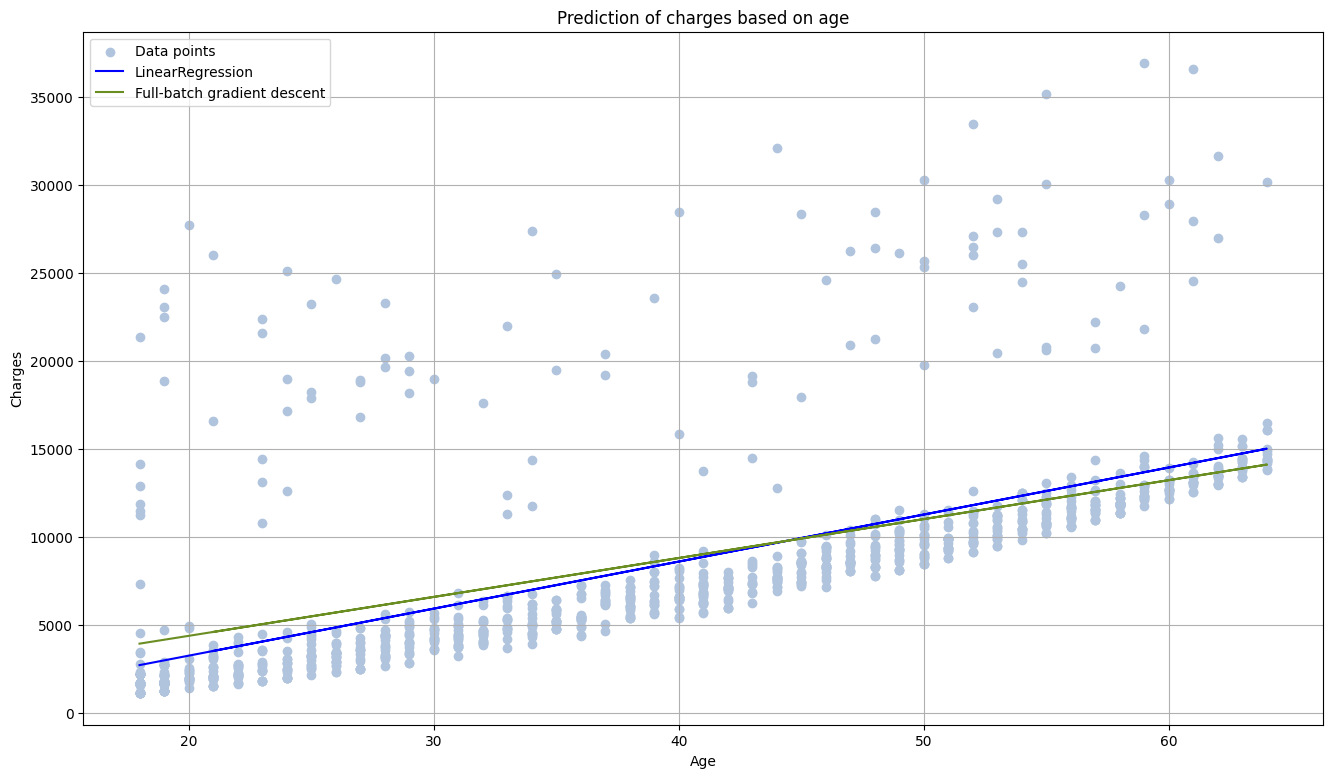

In [42]:
plt.figure(figsize = (16, 9))
plt.scatter(X, y, color = 'lightsteelblue', label = 'Data points')
plt.plot(X, prediction_lin_reg, color = 'blue', label = 'LinearRegression')
plt.plot(X, prediction_4, color = 'olivedrab', label = 'Full-batch gradient descent')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Prediction of charges based on age")
plt.legend()
plt.grid(True)
plt.show()

As can be seen in the graph, or by comparing the coefficients of determination in the case of the Least Squares Method specified using the numpy library, the same results were obtained as in the case of the LinearRegression of the sklearn library. At the same time, according to the quality metrics, the best results are demonstrated by the least squares method. The results of gradient descent at the selected levels of training and the number of iterations showed a slightly worse result.

According to the obtained results, we observe an increase in the level of medical fees by 267.2489 with an increase in the age of non-smokers by 1.

# Building models for smokers

In [43]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [44]:
X_sm = smoker_df['age'].to_frame()
y_sm = smoker_df['charges']

print("Дизайн матриця")
display(X_sm)
print("Цільова змінна")
display(y_sm)

Дизайн матриця


,age
0,19
11,62
14,27
19,30
23,34
...,...
1313,19
1314,30
1321,62
1323,42


Цільова змінна


0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

Finding optimal values ​​of model coefficients

In [45]:
lin_reg_sm = LinearRegression().fit(X_sm, y_sm)

In [46]:
print('Константа:', lin_reg_sm.intercept_.round(4))
print("Коефіцієнт ознаки age:", lin_reg_sm.coef_[0].round(4))

Константа: 20294.1281
Коефіцієнт ознаки age: 305.2376


Forecasting the target variable

In [47]:
prediction_lin_reg_sm = lin_reg_sm.predict(X_sm)

print("Прогнозування charges на основі Методу найменших квадратів з sklearn")
display(prediction_lin_reg_sm[:5])

Прогнозування charges на основі Методу найменших квадратів з sklearn


array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865])

Model quality analysis

In [48]:
rmse_lin_reg_sm = rmse(prediction_lin_reg_sm, y_sm)
r2_lin_reg_sm = r2_score(y_sm, prediction_lin_reg_sm)

print("Середньо квадратична помилка:", rmse_lin_reg_sm.round(4))
print("Коефіцієнт детермінації:", round(r2_lin_reg_sm, 4))

Середньо квадратична помилка: 10711.0033
Коефіцієнт детермінації: 0.1356


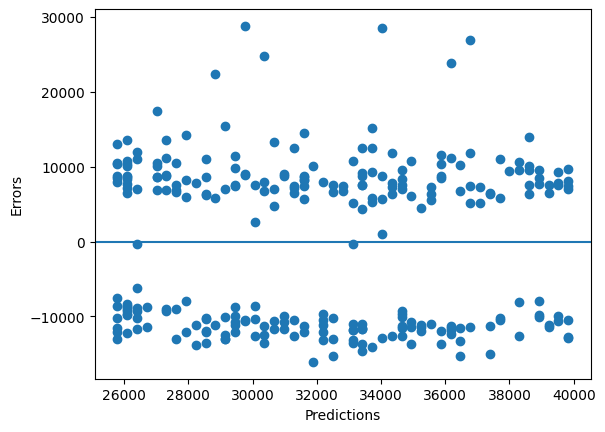

In [49]:
errors_lin_reg_sm = y_sm - prediction_lin_reg_sm

plt.scatter(prediction_lin_reg_sm, errors_lin_reg_sm)
plt.xlabel("Predictions")
plt.ylabel("Errors")
plt.axhline(0)
plt.show();

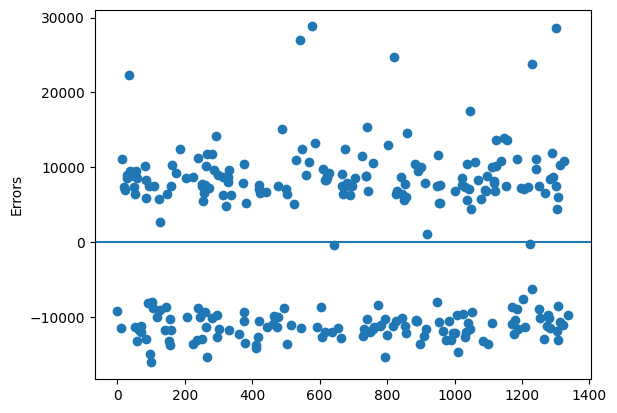

In [50]:
plt.plot(errors_lin_reg_sm, 'o')
plt.ylabel("Errors")
plt.axhline(0)
plt.show();

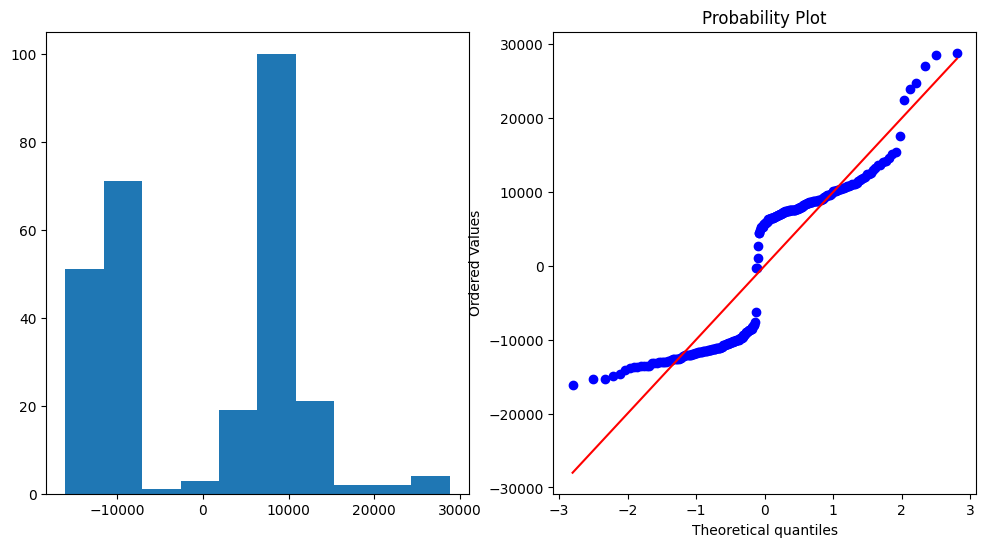

In [51]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(errors_lin_reg_sm)
plt.subplot(1,2,2)
probplot(errors_lin_reg_sm, dist='norm', plot=plt);

Visual representation of results

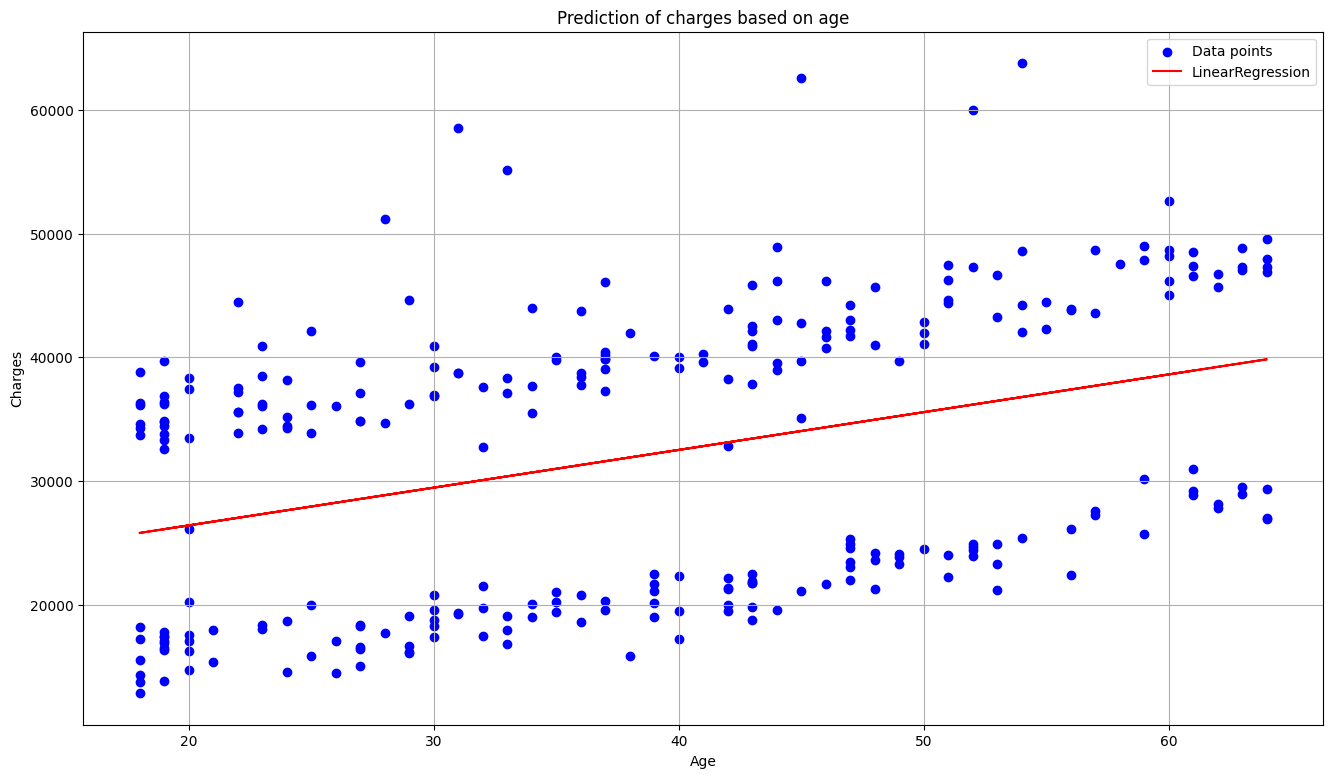

In [52]:
plt.figure(figsize = (16, 9))
plt.scatter(X_sm, y_sm, color = 'blue', label = 'Data points')
plt.plot(X_sm, prediction_lin_reg_sm, color = 'red', label = 'LinearRegression')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Prediction of charges based on age")
plt.legend()
plt.grid(True)
plt.show()

A linear univariate model was constructed using the Least Squares method of the sklearn library, which reflects the relationship between medical fees and the age of smokers.

It describes only 13.56% of the data of the modeled characteristic due to age, the remaining 86.44% of the data depend on other variables. The mean square error is 10711 USD. US dollars. In this case, the distribution of the residuals is not a normal distribution, respectively, the results may not be statistically significant. Regarding heteroscedasticity, there are "two clouds" of residuals without a clear trend, which tends more towards homoscedasticity.

Given the results of the forecasting and distribution of residuals, the modeling of the dependent variable should be continued taking into account other characteristics. This model is not suitable for practical qualitative use.